In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

from graph_generator import generator
from helpers_example import *
from globals import *
from helpers import (
    load_pickle,
    make_parameter_grid,
    split_graph,
    compute_topk_reco,
    compute_pred_metrics,
    markover,
    n2v_embedding,
    fairwalk_embedding,
    compute_results
)
from bias_measures import Bias
from base_models import SVD_embedding

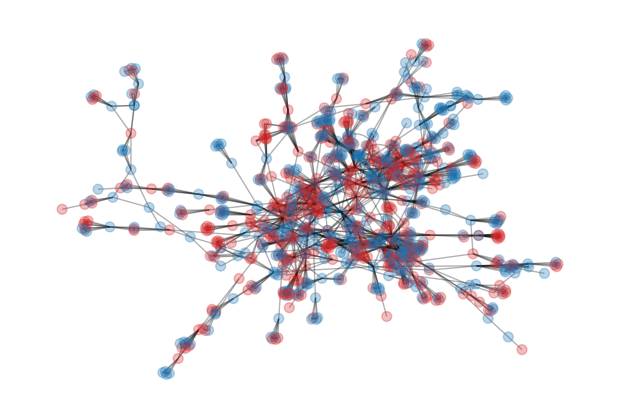

In [2]:
# Loading and drawing Collab real graph

G = load_pickle('data/collab.pkl')
k=10

plot_real_graph(G)


100%|██████████| 4/4 [00:39<00:00,  9.87s/it]


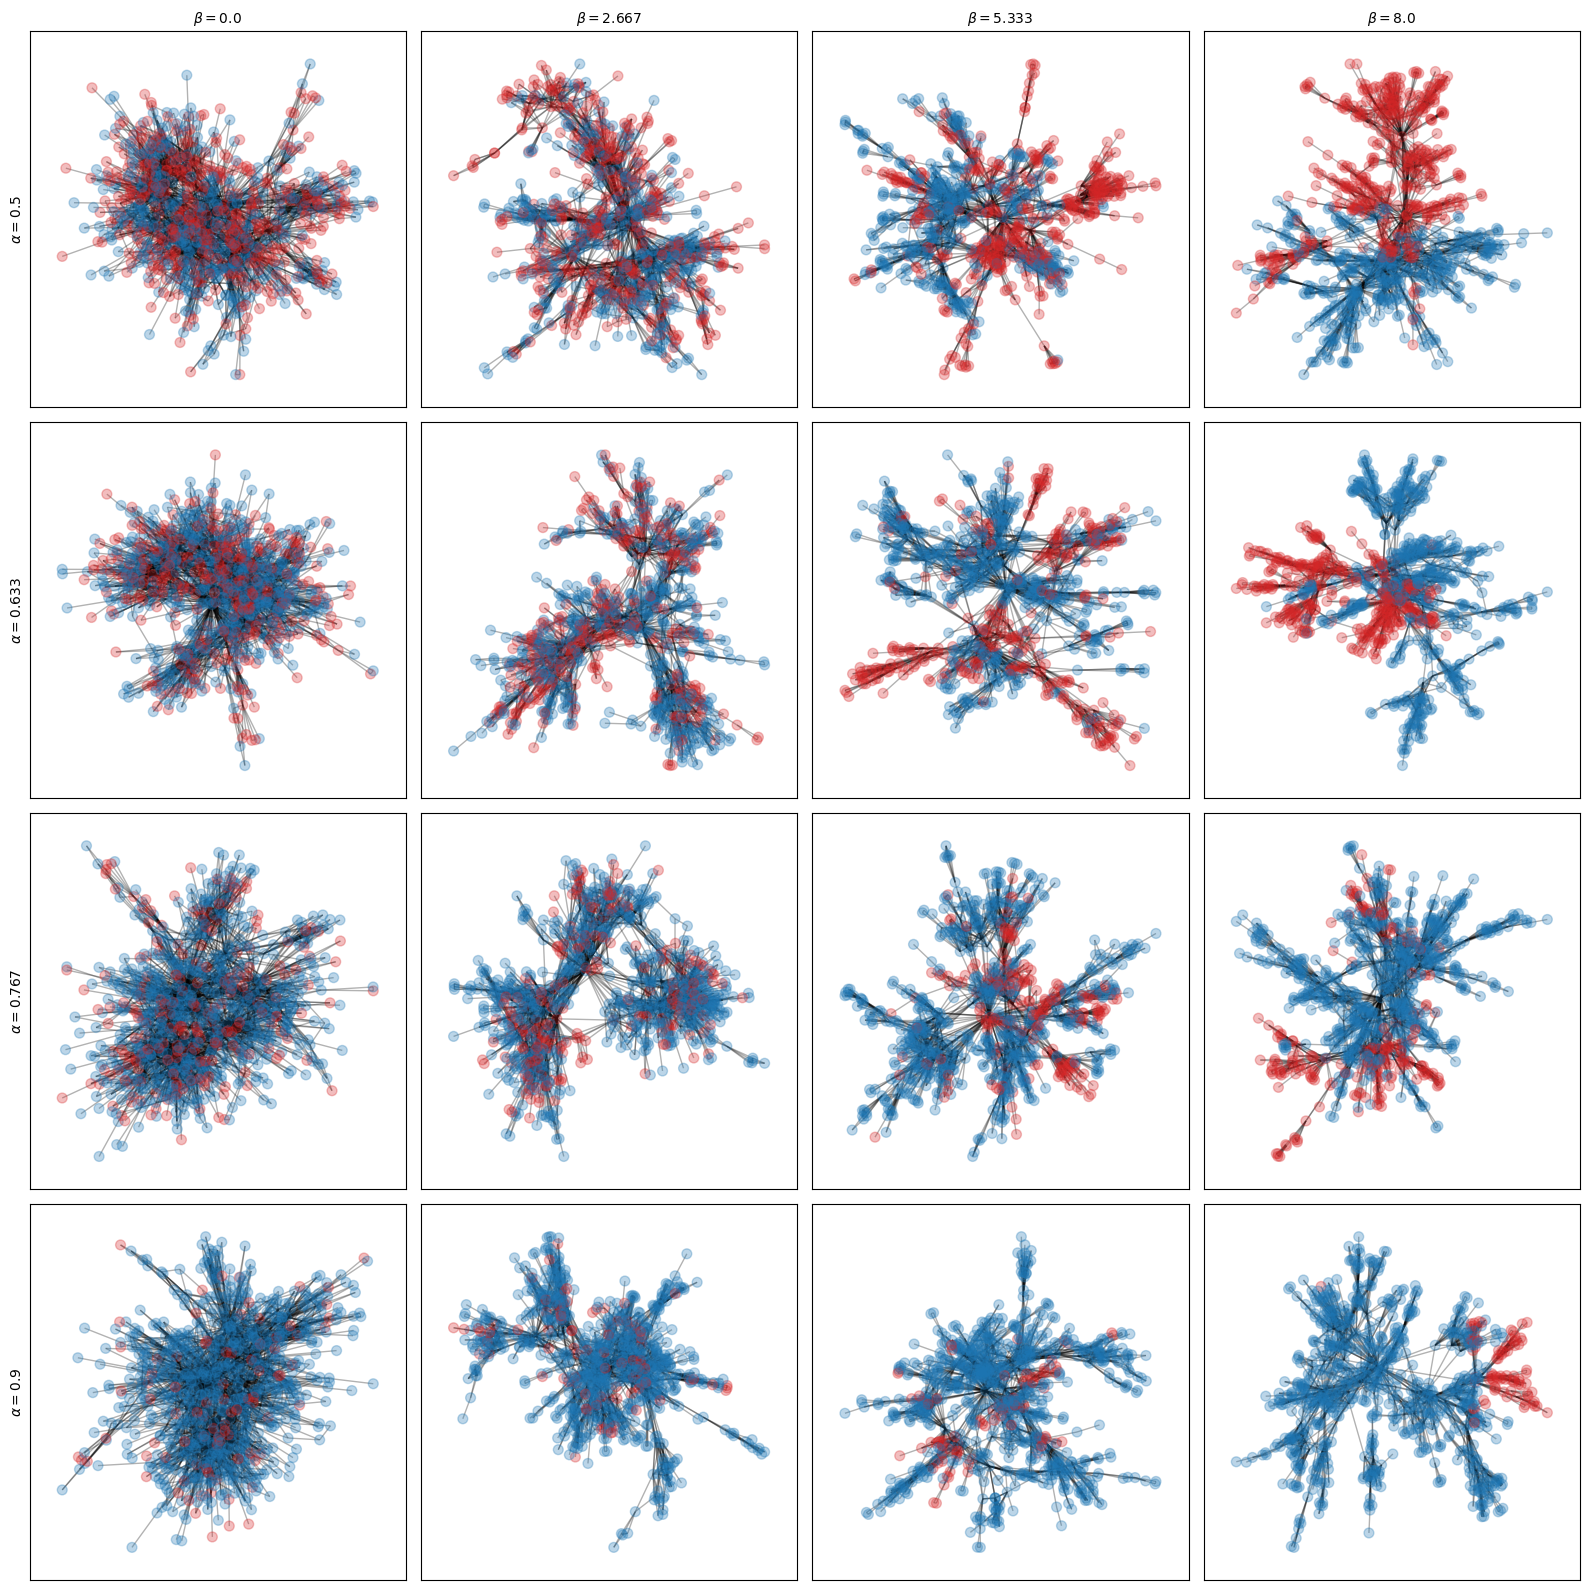

In [3]:
# Generating Collab synthetic graphs with different alpha and beta values

alpha_beta_values = make_parameter_grid(usecase="collab", n_parameter_sample=4)

graphs_dict = {
    (alpha, beta): generator(usecase="collab", alpha=alpha, beta=beta)
    for alpha, beta in tqdm(alpha_beta_values)
}
plot_graph_grid(graphs_dict)

In [4]:
# Computing bias and prediction metrics over the generated graphs

results = dict()

for (alpha, beta), G in tqdm(graphs_dict.items()):
    bias_computer = Bias(G)
    bias_values = bias_computer.compute_bias_values()
    

    G_train, test_edges = split_graph(G)
    embeddings = SVD_embedding(G_train)
    reco = compute_topk_reco(embeddings, G_train)

    pred_metrics = compute_pred_metrics(G_train, reco, test_edges, topk=k)
    results[(alpha, beta)] = pred_metrics | bias_values

df = pd.DataFrame(results).T.reset_index()
df.columns = ['alpha', 'beta'] + list(df.columns[2:])
metrics = list(df.columns[2:])

  0%|          | 0/16 [00:00<?, ?it/s]

Running SVD


  6%|▋         | 1/16 [00:08<02:10,  8.71s/it]

Running SVD


 12%|█▎        | 2/16 [00:16<01:53,  8.14s/it]

...

 88%|████████▊ | 14/16 [02:08<00:19,  9.75s/it]

Running SVD


 94%|█████████▍| 15/16 [02:20<00:10, 10.55s/it]

Running SVD


100%|██████████| 16/16 [02:30<00:00,  9.39s/it]


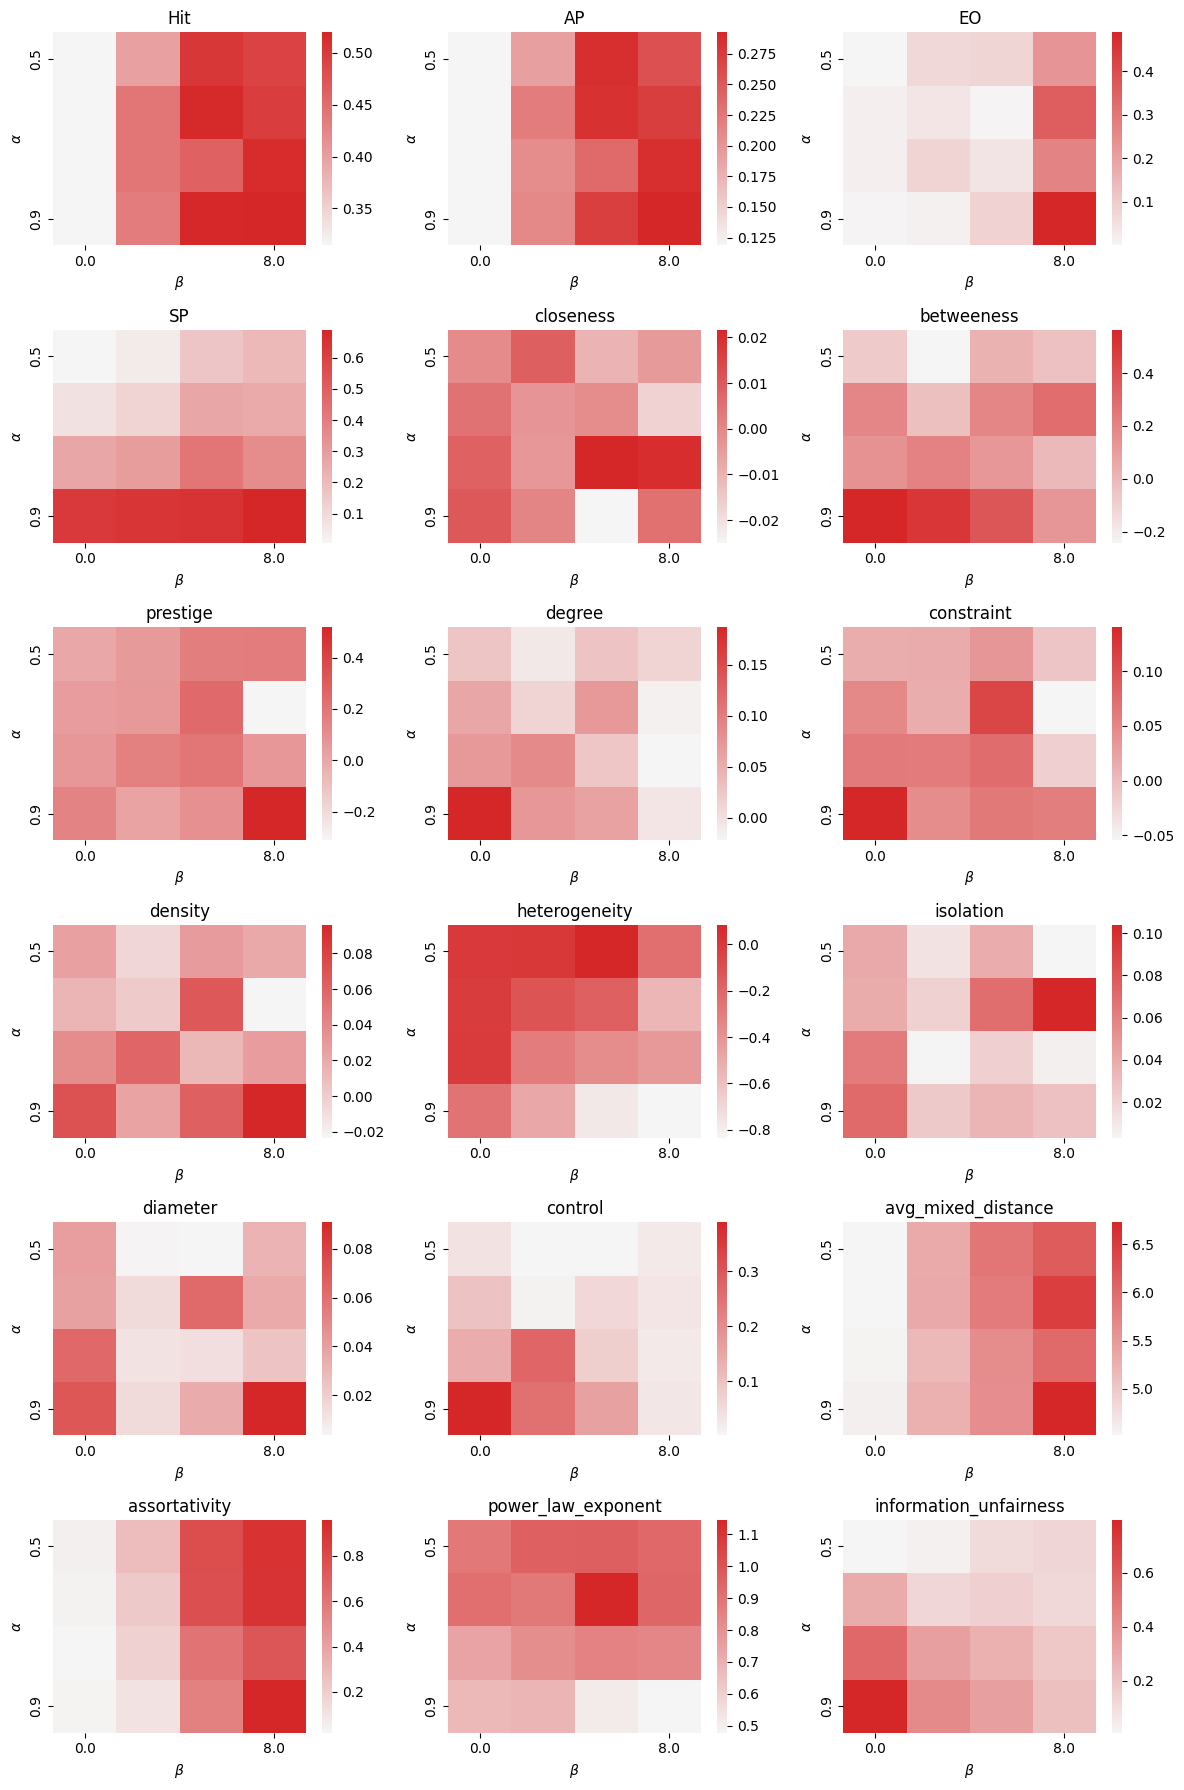

In [5]:
show_heatmaps(df, metrics)

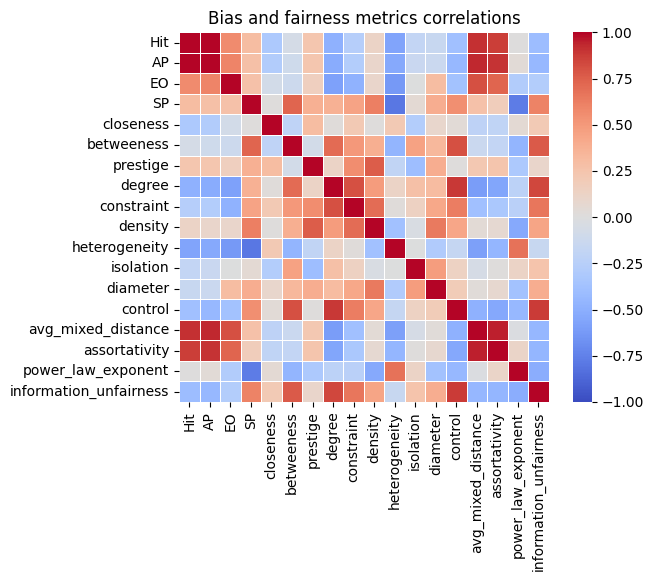

In [6]:
plot_correlations(df, metrics)

In [7]:
df_reg_SP = regression_results(df, "SP")
print("Results for regression on SP values:")
display(df_reg_SP)
df_reg_EO = regression_results(df, "EO")
print("Results for regression on EO values:")
display(df_reg_SP)

Results for regression on SP values:


,input_bias_measures,train_R2,test_R2,train_RMSE,test_RMSE
0,all_bias,0.907559,0.709909,0.068236,0.112383
1,assortativity,0.818068,0.797594,0.095727,0.279755


Results for regression on EO values:


,input_bias_measures,train_R2,test_R2,train_RMSE,test_RMSE
0,all_bias,0.907559,0.709909,0.068236,0.112383
1,assortativity,0.818068,0.797594,0.095727,0.279755


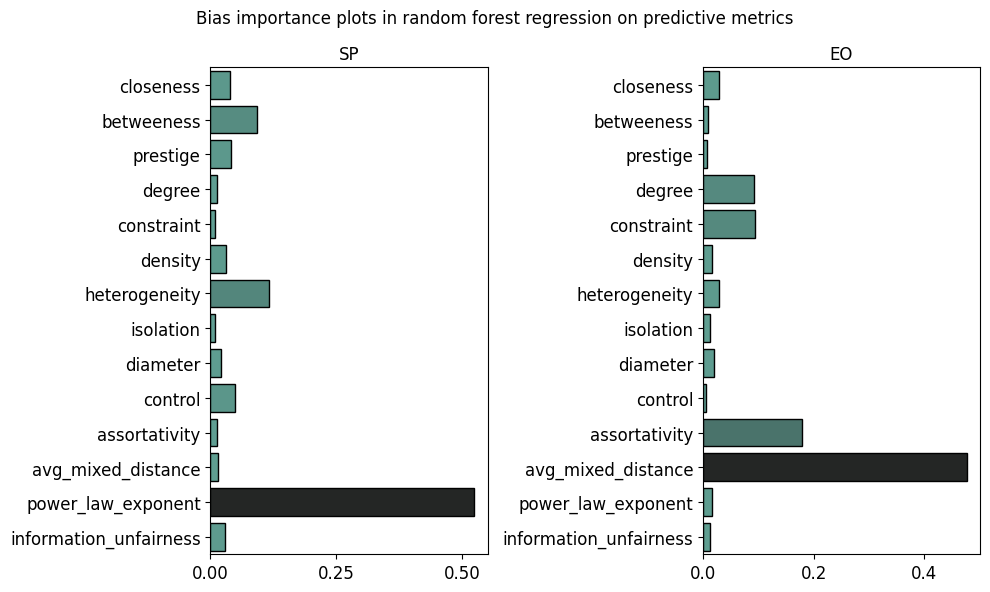

In [8]:
importance_plots(df)

100%|██████████| 16/16 [03:40<00:00, 13.81s/it]


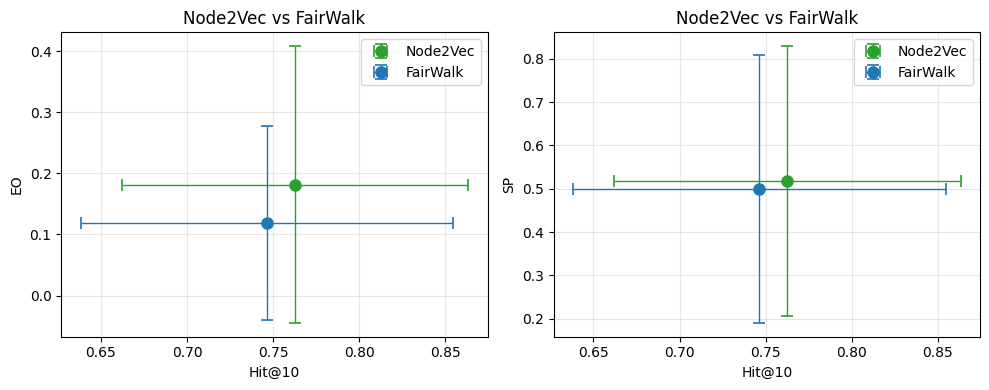

In [9]:
df_n2v, df_fw = compute_results(graphs_dict, k)

METRIC_PAIRS = [
    ("Hit", "Hit@10", "EO", "EO"),
    ("Hit", "Hit@10", "SP", "SP"),
]
models = [
    ("Node2Vec", df_n2v, "tab:green"),
    ("FairWalk", df_fw, "tab:blue"),
]
plot_metric_pairs(models, METRIC_PAIRS)

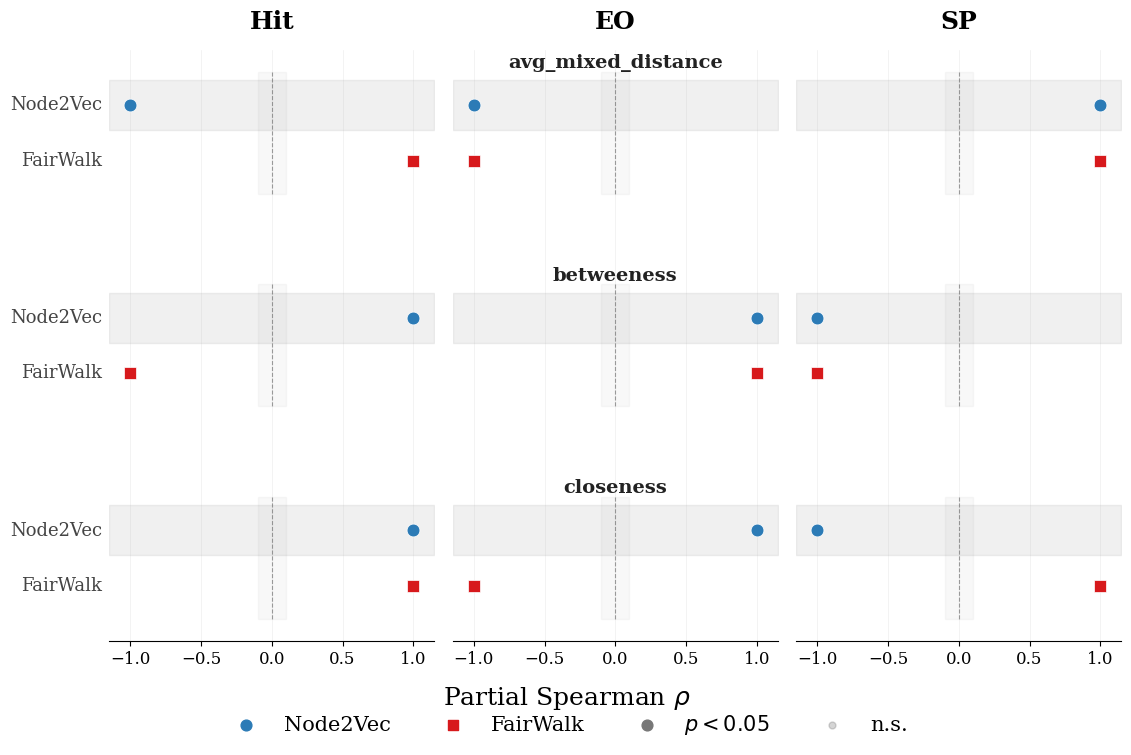

In [10]:
plot_partial_spearman(
    models_data    = {"n2v": df_n2v, "fw": df_fw},
    model_labels   = {"n2v": "Node2Vec", "fw": "FairWalk"}
)